# Resources

- The exercises come from [TorchCode](https://github.com/duoan/TorchCode)
- Andrej Karpathy's famous [NanoGPT](https://github.com/karpathy/nanoGPT) that provides a minimal working walkthrough for modern LLMs
- A very nice follow-up to the above, [BeyondNanoGPT](https://github.com/tanishqkumar/beyond-nanogpt), that implements additional tricks, some of which we'll go through in this notebook
- The classic blog post, [The Illustrated Transformer](https://jalammar.github.io/illustrated-transformer/) is a good place to start if you've never seen transformers before 

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import solutions
import random

# Warm-up #1 Matrix Multiplies

Make random torch tensors $A$ of shape $10\times 5$ and $B$ of shape $5 \times 10$ and compute $AB$

In [ ]:
#TODO

# Warm-up #2 Implement Softmax

Implement the **Softmax** function from scratch.

$$\text{softmax}(x_i) = \frac{e^{x_i}}{\sum_j e^{x_j}}$$

### Signature
```python
def my_softmax(x: torch.Tensor, dim: int = -1) -> torch.Tensor:
    ...
```

### Rules
- Do **NOT** use `torch.softmax`, `F.softmax`, or `torch.nn.Softmax`
- Must be **numerically stable** (hint: subtract `max` before `exp`)

### Example
```
Input:  tensor([1., 2., 3.])
Output: tensor([0.0900, 0.2447, 0.6652])  # sums to 1.0
```

In [ ]:
def my_softmax(x: torch.Tensor, dim: int = -1) -> torch.Tensor:
    #TODO
    pass

Scratch work

In [ ]:
x = torch.tensor([2.0, 1.0, 0.1])
#TODO

Tests

In [ ]:
logits = torch.tensor([2.0, 1.0, 0.1])

torch.allclose(my_softmax(logits), torch.softmax(logits, dim=0), atol=1e-07, equal_nan=True)

# Feed Forward Network

$$f_{\text{MLP}} = f_{\text{FC}} \circ \text{GELU} \circ f_{\text{FC}}$$

### Signature
```python
class mlp(x: torch.Tensor) -> torch.Tensor:
    def __init__(self, d_input: int, d_hidden: int, d_output: int): ...
    def forward(self, x) -> torch.Tensor: ...
    ...
```

In [ ]:
class MLP(nn.Module):
    def __init__(self, d_input: int, d_hidden: int, d_output: int): 
        super().__init__()
        #TODO
        pass
        
    def forward(self, x) -> torch.Tensor: 
        #TODO
        pass

Tests

In [ ]:
batch, d_input, d_hidden, d_output = 5, 50, 100, 10
batch_inputs = torch.rand((batch, d_input))
mlp = MLP(d_input, d_hidden, d_output)
out = mlp(batch_inputs)
print(out.shape==(batch, d_output))

# Vanilla attention

Implement the core attention mechanism used in Transformers.

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

### Signature
```python
def scaled_dot_product_attention(
    Q: torch.Tensor,  # (batch, seq_q, d_k)
    K: torch.Tensor,  # (batch, seq_k, d_k)
    V: torch.Tensor,  # (batch, seq_k, d_v)
) -> torch.Tensor:   # (batch, seq_q, d_v)
    ...
```

Scratch work

In [ ]:
Q = torch.rand(5, 10, 50)
K = torch.rand(5, 10, 50)
V = torch.rand(5, 10, 50)

#TODO

In [ ]:
def scaled_dot_product_attention(Q, K, V):
    #TODO
    pass

Tests

In [ ]:
Q = torch.rand(5, 10, 50)
K = torch.rand(5, 10, 50)
V = torch.rand(5, 10, 50)

torch.allclose(scaled_dot_product_attention(Q,K,V), 
               solutions.scaled_dot_product_attention_solution(Q,K,V), 
               atol=1e-07, equal_nan=True)

# Multi-head attention

Implement **Multi-Head Attention** from scratch — the core building block of the Transformer.

$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \dots, \text{head}_h) W^O$$
$$\text{head}_i = \text{Attention}(Q W_i^Q,\; K W_i^K,\; V W_i^V)$$

### Signature
```python
class MultiHeadAttention:
    def __init__(self, d_model: int, num_heads: int): ...
    def forward(self, Q, K, V) -> torch.Tensor: ...
```

### Requirements
- Use `nn.Linear(d_model, d_model)` for `self.W_q`, `self.W_k`, `self.W_v`, `self.W_o`
- `d_k = d_model // num_heads` per head
- `forward(Q, K, V)`: Q is `(B, seq_q, d_model)`, K/V are `(B, seq_k, d_model)`
- Must support **cross-attention** (`seq_q != seq_k`)
- Do **NOT** use `torch.nn.MultiheadAttention`
- You **may** use `torch.softmax` and `torch.matmul`

### Steps
1. Project: `q = self.W_q(Q)`, `k = self.W_k(K)`, `v = self.W_v(V)`
2. Reshape to `(B, num_heads, seq, d_k)`
3. Scaled dot-product attention per head
4. Concat heads → `(B, seq_q, d_model)`
5. Output projection: `self.W_o(concat)`

Scratch work

In [ ]:
q = torch.rand(5, 10, 50)
k = torch.rand(5, 10, 50)
v = torch.rand(5, 10, 50)

#TODO

In [ ]:
class MultiHeadAttention:
    def __init__(self, d_model, num_heads):
        #TODO
        pass

    def forward(self, Q, K, V):
        #TODO
        pass

Tests

In [ ]:
d_model = 50
num_heads = 5
Q = torch.rand(5, 10, d_model)
K = torch.rand(5, 10, d_model)
V = torch.rand(5, 10, d_model)

mha = MultiHeadAttention(d_model, num_heads)
mha_solution = solutions.MultiHeadAttentionSolution(d_model, num_heads)
print(mha.forward(Q,K,V).shape == mha_solution.forward(Q,K,V).shape)

# GPT-2 Transformer Block

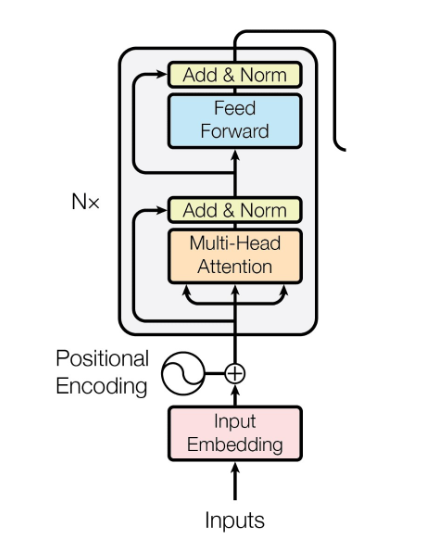

Implement a full **GPT-2 style Transformer block** — combining everything you've learned.

### Architecture (Pre-Norm)
```
x = x + causal_self_attention(ln1(x))
x = x + mlp(ln2(x))
```

### Signature
```python
class GPT2Block(nn.Module):
    def __init__(self, d_model: int, num_heads: int): ...
    def forward(self, x: torch.Tensor) -> torch.Tensor: ...
```

### Requirements
- Inherit from `nn.Module`
- `self.ln1`, `self.ln2`: `nn.LayerNorm(d_model)`
- `self.W_q`, `self.W_k`, `self.W_v`, `self.W_o`: `nn.Linear` for attention
- `self.mlp`: `nn.Sequential(Linear(d, 4d), GELU(), Linear(4d, d))`
- Attention must be **causal** (mask future positions)
- Pre-norm architecture (LayerNorm *before* attention and MLP)
- Residual connections around both attention and MLP

Scratch work

In [ ]:
q = torch.rand(5, 10, 50)
k = torch.rand(5, 10, 50)
v = torch.rand(5, 10, 50)

In [ ]:
class GPT2Block(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        pass
        
    def attn(self, x):
        pass
        
    def forward(self, x):
        pass

Tests

In [ ]:
d_model = 50
num_heads = 5
batch = 20
seq = 10
x = torch.rand(batch, seq, d_model)

gpt2 = GPT2Block(d_model, num_heads)
out = gpt2(x)
print(out.shape == (batch, seq, d_model))

# LoRA (Low-Rank Adaptation)

Implement **LoRA** — parameter-efficient fine-tuning for large models.

$$h = W_0 x + \frac{\alpha}{r} B A x$$

### Signature
```python
class LoRALinear(nn.Module):
    def __init__(self, in_features, out_features, rank, alpha=1.0): ...
    def forward(self, x: Tensor) -> Tensor: ...
```

### Requirements
- `self.linear`: frozen `nn.Linear` (weight & bias `requires_grad=False`)
- `self.lora_A`: `nn.Parameter(rank, in_features)` — random init
- `self.lora_B`: `nn.Parameter(out_features, rank)` — **zero** init
- Scaling: `alpha / rank`

In [ ]:
class LoRALinear(nn.Module):
    def __init__(self, in_features, out_features, rank, alpha=1.0):
        super().__init__()
        pass
        
    def forward(self, x):
        pass

In [ ]:
batch = 5
in_features = 50
out_features = 60

batch_inputs = torch.Tensor(batch, in_features)

lora = LoRALinear(in_features, out_features, 10)
lora_outputs = lora(batch_inputs)
print(lora_outputs.shape==(batch, out_features))

# Grouped Query Attention (GQA)

Implement **Grouped Query Attention** — used in LLaMA 2, Mistral, etc. to reduce KV cache size.

Like MHA, but with **fewer KV heads** than Q heads. Each group of Q heads shares the same K/V head.

### Signature
```python
class GroupQueryAttention:
    def __init__(self, d_model: int, num_heads: int, num_kv_heads: int): ...
    def forward(self, x) -> torch.Tensor:  # self-attention
```

### Requirements
- `self.W_q`: `nn.Linear(d_model, d_model)` — full Q projection
- `self.W_k`: `nn.Linear(d_model, num_kv_heads * d_k)` — reduced K projection
- `self.W_v`: `nn.Linear(d_model, num_kv_heads * d_k)` — reduced V projection
- `self.W_o`: `nn.Linear(d_model, d_model)` — output projection
- `d_k = d_model // num_heads`
- Expand KV heads with `repeat_interleave` to match Q heads
- When `num_kv_heads == num_heads`, should behave like standard MHA

Scratch work

In [ ]:
q = torch.rand(5, 10, 100)
k = torch.rand(5, 10, 50)
v = torch.rand(5, 10, 50)

#TODO

In [ ]:
class GroupQueryAttention:
    def __init__(self, d_model, num_heads, num_kv_heads):
        pass #TODO

    def forward(self, x):
        pass #TODO

# Flash Attention (Tiled)

Implement **tiled attention with online softmax** — the core idea behind Flash Attention.

### Signature
```python
def flash_attention(Q, K, V, block_size=32) -> Tensor:
    # Q, K, V: (B, S, D)
    # Returns: (B, S, D) — same as standard attention
```

### Key Insight
Instead of materializing the full S×S attention matrix, process in blocks:
1. For each Q-block, iterate over K/V blocks
2. Use **online softmax**: track running `max` and `sum`
3. Rescale accumulator when max changes: `acc *= exp(old_max - new_max)`
4. Final: `output = acc / row_sum`

Must give **identical** results to standard softmax attention.

In [ ]:
def flash_attention(Q, K, V, block_size=32):
    # Process Q in blocks, iterate K/V blocks with online softmax
    pass

# Mixture of Experts (MoE)

Implement a **Mixture of Experts** layer (Mixtral / Switch Transformer style).

### Signature
```python
class MixtureOfExperts(nn.Module):
    def __init__(self, d_model, d_ff, num_experts, top_k=2): ...
    def forward(self, x: Tensor) -> Tensor:
        # x: (B, S, D) -> (B, S, D)
```

### Architecture
- `self.router`: `nn.Linear(d_model, num_experts)` — gating network
- `self.experts`: `nn.ModuleList` of MLPs `(Linear→ReLU→Linear)`
- For each token: select top-k experts, compute weighted sum of their outputs

In [ ]:
class MixtureOfExperts(nn.Module):
    def __init__(self, d_model, d_ff, num_experts, top_k=2):
        super().__init__()
        pass

    def forward(self, x):
        pass

# KV Cache Attention

Implement **multi-head attention with KV caching** for efficient autoregressive generation.

During LLM inference, recomputing all key/value projections at every step is wasteful.
A **KV cache** stores previously computed K and V tensors so only the new token(s) need projection.

### Signature
```python
class KVCacheAttention(nn.Module):
    def __init__(self, d_model: int, num_heads: int): ...
    def forward(self, x: torch.Tensor, cache=None) -> tuple[torch.Tensor, tuple]:
        # x: (B, S_new, D) — new tokens
        # cache: None or (K_past, V_past) each (B, num_heads, S_past, d_k)
        # Returns: (output, (K_all, V_all))
```

### Requirements
- Inherit from `nn.Module`
- `self.W_q`, `self.W_k`, `self.W_v`, `self.W_o`: `nn.Linear` projections
- When `cache=None` (prefill): apply **causal mask**, return all K/V as cache
- When `cache` provided (decode): concat new K/V with cached, no causal mask needed for single-token decode
- Incremental decode must produce **identical** results to full forward pass

### Key Idea
```
Prefill:  [t0 t1 t2 t3] → full causal attention → cache = (K_{0:3}, V_{0:3})
Decode:   [t4]           → Q=t4, K/V=cache+t4  → cache = (K_{0:4}, V_{0:4})
Decode:   [t5]           → Q=t5, K/V=cache+t5  → cache = (K_{0:5}, V_{0:5})
```